# Parte 4 — LoRA (Low-Rank Adaptation)
### Fine-tuning eficiente en parámetros

**Prerequisito:** haber ejecutado `part-1-data.ipynb`

LoRA congela los pesos pre-entrenados e inyecta matrices de bajo rango entrenables en paralelo:

$$W' = W + \Delta W = W + B \cdot A$$

donde $A \in \mathbb{R}^{r \times k}$ y $B \in \mathbb{R}^{d \times r}$, con rango $r \ll \min(d, k)$.

```
Entrada x
  ├──► W (congelado)  ──────────────────┐
  └──► A (entrenable) → B (entrenable) ─(+)→ salida
```

In [ ]:
# !pip install 'transformers[torch]' 'accelerate>=1.1.0' peft datasets evaluate scikit-learn -q

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from dotenv import load_dotenv
import os

SEED             = 42
MODEL_CHECKPOINT = "distilbert-base-uncased"
DATASET_PATH     = "./tokenized_dataset"
HF_REPO          = "jdmartinev/imdb-distilbert-lora"  # <-- cambia esto
LORA_SAVE_PATH   = "./checkpoints/lora_adapters"
BATCH_SIZE       = 32
EPOCHS           = 2
LR               = 2e-4   # más alto que full FT — pocos parámetros entrenables
ID2LABEL         = {0: "negative", 1: "positive"}
LABEL2ID         = {"negative": 0, "positive": 1}

torch.manual_seed(SEED)
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

load_dotenv()  # reads .env and sets environment variables
token = os.environ["HF_TOKEN"]

Device: cuda


## 1. Cargar dataset tokenizado

In [2]:
tokenized_dataset = load_from_disk(DATASET_PATH)
tokenizer         = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
data_collator     = DataCollatorWithPadding(tokenizer=tokenizer)
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


## 2. Inspección de módulos

Antes de aplicar LoRA necesitamos saber los nombres exactos de las capas lineales para `target_modules`.

In [3]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID)

print("Módulos lineales disponibles:")
for name, module in base_model.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f"  {name}  [{module.in_features} → {module.out_features}]")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Módulos lineales disponibles:
  distilbert.transformer.layer.0.attention.q_lin  [768 → 768]
  distilbert.transformer.layer.0.attention.k_lin  [768 → 768]
  distilbert.transformer.layer.0.attention.v_lin  [768 → 768]
  distilbert.transformer.layer.0.attention.out_lin  [768 → 768]
  distilbert.transformer.layer.0.ffn.lin1  [768 → 3072]
  distilbert.transformer.layer.0.ffn.lin2  [3072 → 768]
  distilbert.transformer.layer.1.attention.q_lin  [768 → 768]
  distilbert.transformer.layer.1.attention.k_lin  [768 → 768]
  distilbert.transformer.layer.1.attention.v_lin  [768 → 768]
  distilbert.transformer.layer.1.attention.out_lin  [768 → 768]
  distilbert.transformer.layer.1.ffn.lin1  [768 → 3072]
  distilbert.transformer.layer.1.ffn.lin2  [3072 → 768]
  distilbert.transformer.layer.2.attention.q_lin  [768 → 768]
  distilbert.transformer.layer.2.attention.k_lin  [768 → 768]
  distilbert.transformer.layer.2.attention.v_lin  [768 → 768]
  distilbert.transformer.layer.2.attention.out_lin  [768 → 7

## 3. Configurar y aplicar LoRA

In [4]:
lora_config = LoraConfig(
    task_type        = TaskType.SEQ_CLS,
    r                = 8,          # rango — más alto = más capacidad, más parámetros
    lora_alpha       = 16,         # escala: el update real es (alpha/r) * BA
    lora_dropout     = 0.1,
    target_modules   = ["q_lin", "v_lin"],   # query y value en cada capa
    bias             = "none",
    modules_to_save  = ["pre_classifier", "classifier"],  # estas capas se entrenan completas
)

model_lora = get_peft_model(base_model, lora_config)
model_lora.print_trainable_parameters()

print("\nEstructura de la primera capa de atención con LoRA:")
print(model_lora.base_model.distilbert.transformer.layer[0].attention)

trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925

Estructura de la primera capa de atención con LoRA:
DistilBertSelfAttention(
  (q_lin): lora.Linear(
    (base_layer): Linear(in_features=768, out_features=768, bias=True)
    (lora_dropout): ModuleDict(
      (default): Dropout(p=0.1, inplace=False)
    )
    (lora_A): ModuleDict(
      (default): Linear(in_features=768, out_features=8, bias=False)
    )
    (lora_B): ModuleDict(
      (default): Linear(in_features=8, out_features=768, bias=False)
    )
    (lora_embedding_A): ParameterDict()
    (lora_embedding_B): ParameterDict()
    (lora_magnitude_vector): ModuleDict()
  )
  (k_lin): Linear(in_features=768, out_features=768, bias=True)
  (v_lin): lora.Linear(
    (base_layer): Linear(in_features=768, out_features=768, bias=True)
    (lora_dropout): ModuleDict(
      (default): Dropout(p=0.1, inplace=False)
    )
    (lora_A): ModuleDict(
      (default): Linear(in_features=768, out_features=8, bias=False)
 

## 4. Métricas

In [5]:
acc_metric = evaluate.load("accuracy")
f1_metric  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

## 5. Entrenamiento

In [6]:
n_train_steps = (len(tokenized_dataset["train"]) // BATCH_SIZE) * EPOCHS

training_args = TrainingArguments(
    output_dir                  = "./checkpoints/lora",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_steps                = int(0.1 * n_train_steps),
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    logging_steps               = 50,
    report_to                   = "none",
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
)

trainer = Trainer(
    model             = model_lora,
    args              = training_args,
    train_dataset     = tokenized_dataset["train"],
    eval_dataset      = tokenized_dataset["validation"],
    processing_class  = tokenizer,
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.308478,0.289607,0.880000,0.879990
2,0.281942,0.278361,0.883500,0.883493


TrainOutput(global_step=500, training_loss=0.33741992950439453, metrics={'train_runtime': 93.992, 'train_samples_per_second': 170.227, 'train_steps_per_second': 5.32, 'total_flos': 1077915254784000.0, 'train_loss': 0.33741992950439453, 'epoch': 2.0})

## 6. Curvas de entrenamiento

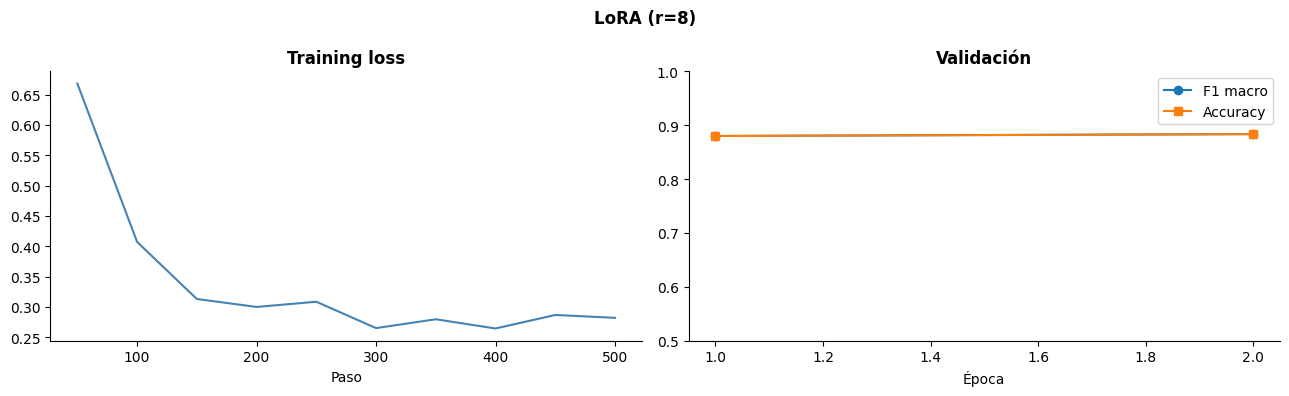

In [7]:
logs       = pd.DataFrame(trainer.state.log_history)
train_logs = logs[logs["loss"].notna()]
eval_logs  = logs[logs["eval_loss"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_logs["step"], train_logs["loss"], color="steelblue")
axes[0].set_title("Training loss", fontweight="bold"); axes[0].set_xlabel("Paso")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(eval_logs["epoch"], eval_logs["eval_f1_macro"], marker="o", label="F1 macro")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_accuracy"], marker="s", label="Accuracy")
axes[1].set_title("Validación", fontweight="bold"); axes[1].set_xlabel("Época")
axes[1].set_ylim(0.5, 1.0); axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("LoRA (r=8)", fontweight="bold"); plt.tight_layout(); plt.show()

## 7. Evaluación en test

              precision    recall  f1-score   support

    negative     0.8992    0.8740    0.8864      1000
    positive     0.8774    0.9020    0.8895      1000

    accuracy                         0.8880      2000
   macro avg     0.8883    0.8880    0.8880      2000
weighted avg     0.8883    0.8880    0.8880      2000



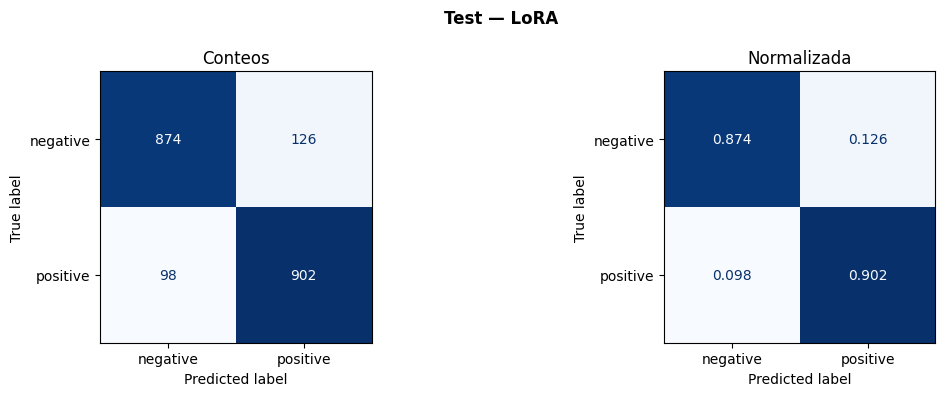

{'test_loss': 0.2657773196697235, 'test_accuracy': 0.888, 'test_f1_macro': 0.8879780436965645, 'test_runtime': 4.6584, 'test_samples_per_second': 429.33, 'test_steps_per_second': 13.524}


In [8]:
output = trainer.predict(tokenized_dataset["test"])
preds  = np.argmax(output.predictions, axis=1)
labels = output.label_ids

print(classification_report(labels, preds, target_names=["negative", "positive"], digits=4))

cm = confusion_matrix(labels, preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Conteos")
ConfusionMatrixDisplay(cm.astype(float)/cm.sum(axis=1,keepdims=True),
                       display_labels=["negative","positive"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".3f")
axes[1].set_title("Normalizada")
plt.suptitle("Test — LoRA", fontweight="bold")
plt.tight_layout(); plt.show()

metrics_lora = output.metrics
print(metrics_lora)

## 8. Guardar adaptadores y push to Hub

`save_pretrained` guarda **solo los adaptadores** (~KB), no el modelo base completo (~268 MB).

In [9]:
model_lora.save_pretrained(LORA_SAVE_PATH)
tokenizer.save_pretrained(LORA_SAVE_PATH)

print("Archivos guardados:")
for f in os.listdir(LORA_SAVE_PATH):
    size = os.path.getsize(os.path.join(LORA_SAVE_PATH, f)) / 1024
    print(f"  {f:<40}  {size:>8.1f} KB")

Archivos guardados:
  tokenizer.json                               694.7 KB
  adapter_model.safetensors                   2892.8 KB
  README.md                                      5.0 KB
  tokenizer_config.json                          0.3 KB
  adapter_config.json                            1.0 KB


In [13]:
# Para el notebook de comparación necesitamos el modelo fusionado (merge_and_unload)
# Esto aplica W' = W + BA y devuelve un modelo estándar sin overhead PEFT
merged_model = model_lora.merge_and_unload()
merged_model.push_to_hub(HF_REPO, commit_message="LoRA r=8 — merged")
tokenizer.push_to_hub(HF_REPO)
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Modelo publicado en: https://huggingface.co/jdmartinev/imdb-distilbert-lora
